# Computer Vision and Deep Learning - Laboratory 3

In this laboratory session, we'll be diving into deep convolutional neural networks.

In [ ]:
!pip install opencv-python
# !pip install matplotlib

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install torchvision

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   --------- ------------------------------ 1.0/4.3 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 18.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


import torch
import torchvision
import torchvision.transforms as transforms

In [12]:

!wget https://www.math.hkust.edu.hk/~masyleung/Teaching/CAS/MATLAB/image/images/cameraman.jpg


'wget' is not recognized as an internal or external command,
operable program or batch file.


# Warm-up


Let's start by implementing the basic blocks of a convolutional neural network: the convolutional and (optional) the pooling operations. This would be the last "low-level" implementation that you'll do for this class.

## Convolutions

The convolutional layer is the main building block of a convolutional neural network. These layers contain a set of learnable filters, which will learn which features are relevant for the classification problem based on the training data.
During the forward pass, each filter (which __must__ have the same depth as the input volume) is slided over the spatial dimensions of the input volume and we compute an element-wise multiplication between the filter weights and the region of interest in the input volume that lies beneath the filter.

The hyperparameters of a convolutional layer are:
- the filter size F (usually this is an odd value);
- the padding amount which will be added to the input volume P;
- the stride S (or the step used when sliding across the input volume);
- the number of filters k; the depth of each filter must match the depth of the input volume;

Given an input volume of shape  ($H_i$, $W_i$, $D$), the convolutional layer will produce an output of shape ($H_o$, $W_o$, $k$), where:

\begin{equation}
W_o = \frac{W_i - F + 2P}{S} + 1
\end{equation}

\begin{equation}
H_o = \frac{H_i - F + 2P}{S} + 1
\end{equation}

<img src="https://lh6.googleusercontent.com/gZxwFH6mQ5tPjz6LzVbOaNeVuR1NC-BnuemIWO41qnn7r1PvP4qzwXRWC1OJgo2_PD08qaqJ2-VCF3q9laeK885IJwK-dHhpLDkvRZrx4vxrbLDTsKD2iZYM5SFRq4A6XTklk7_h"/>

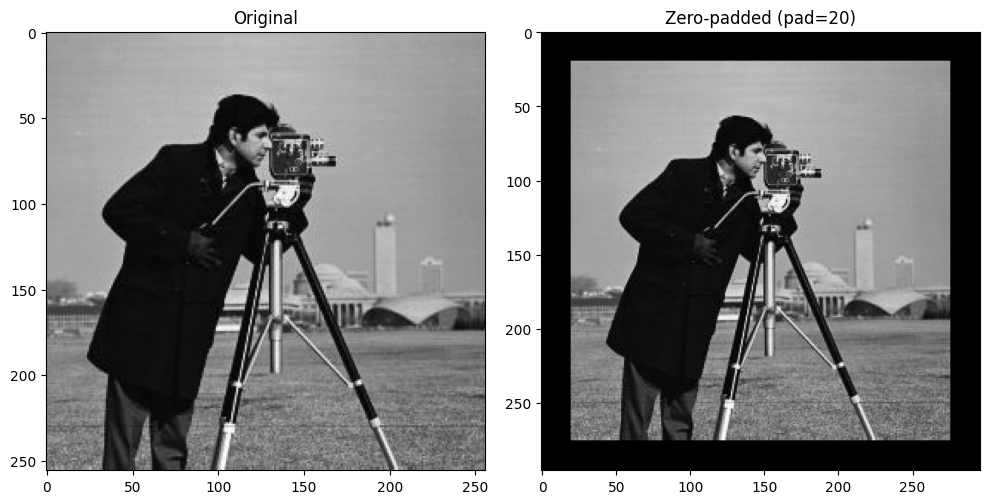

In [2]:
def zero_pad(X, pad):
  """
  This function applies the zero padding operation on all the images in the array X
  :param X input array of images; this array has a of rank 4 (batch_size, height, width, channels)
  :param pad the amount of zeros to be added around around the spatial size of the images
  """
  return np.pad(X, ((0, 0), (pad, pad), (pad, pad), (0, 0)), mode='constant', constant_values=0)

img = cv2.imread('cameraman.jpg', cv2.IMREAD_GRAYSCALE)
img = np.asarray(img)

img_4d = img[np.newaxis, :, :, np.newaxis]
img_padded = zero_pad(img_4d, pad=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(img_padded[0, :, :, 0], cmap='gray')
axes[1].set_title("Zero-padded (pad=20)")
plt.tight_layout()
plt.show()

In [3]:
def convolution(X, W, bias, pad, stride):
  """
  This function applied to convolution operation on the input X of shape (num_samples, iH, iW, iC)
  using the filters defined by the W (filter weights) and  (bias) parameters.

  :param X - input of shape (num_samples, iH, iW, iC)
  :param W - weights, numpy array of shape (fs, fs, iC, k), where fs is the filter size,
    iC is the depth of the input volum and k is the number of filters applied on the image
  :param biases - numpy array of shape (1, 1, 1, k)
  :param pad - hyperparameter, the amount of padding to be applied
  :param stride - hyperparameter, the stride of the convolution
  """

  # 0. compute the size of the output activation map and initialize it with zeros

  num_samples = X.shape[0]
  iW = X.shape[2]
  iH = X.shape[1]
  f = W.shape[0]

  oH = (iH - f + 2 * pad) // stride + 1
  oW = (iW - f + 2 * pad) // stride + 1
  oC = W.shape[3]
  activation_map = np.zeros((num_samples, oH, oW, oC))

  X_padded = zero_pad(X, pad)

  for i in range(num_samples):
    X_i = X_padded[i]

    for y in range(oH):
      tl_y = y * stride
      br_y = tl_y + f

      for x in range(oW):
        tl_x = x * stride
        br_x = tl_x + f

        for c in range(oC):
            roi = X_padded[i, tl_y: br_y, tl_x: br_x, :]
            w = W[:, :, :, c]
            b = bias[:, :, :, c]

            a = np.multiply(roi, w)
            a = np.sum(a)
            a = a + float(b)

            activation_map[i, y, x, c] = a
        assert(activation_map.shape == (num_samples, oH, oW, oC))
  return activation_map



np.random.seed(10)
# 100 samples of shape (13, 21, 4)
X = np.random.randn(100, 13, 21, 4)

# 8 filters (last dimension) of shape (3, 3)
W = np.random.randn(3, 3, 4, 8)
b = np.random.randn(1, 1, 1, 8)

am = convolution(X, W, b, pad=1, stride=2)
print("am's mean =\n", np.mean(am))
print("am[1, 2, 3] =\n", am[3,2,1])


C:\Users\Andreea\AppData\Local\Temp\ipykernel_33976\3569382599.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a = a + float(b)


am's mean =
 -0.4284130223223714
am[1, 2, 3] =
 [ 1.78081902 -6.51813947 -4.35815226 -2.91158344  1.84016713 -3.72264278
 -8.32761753 -3.22778695]


Expected output:

am's mean =
 -0.42841306

am[1, 2, 3] =
 [ 1.780819  -6.5181394 -4.3581524 -2.9115834  1.8401672 -3.722643
 -8.327618  -3.227787 ]

Now let's analyse the effect of applying some well known filters used in image processing.

### Low pass filters
Low pass filters are used to keep the low frequency information within an, while reducing the high frequency information. These filters are the basis of image smoothing.

Two well known low pass filters are the _mean filter_ and the _Gaussian filter_.

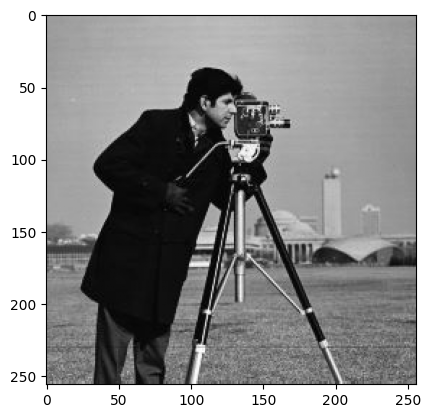

In [4]:
image = cv2.imread('cameraman.jpg', cv2.IMREAD_GRAYSCALE)
image = np.expand_dims(image, axis=-1)

# X contains a single image sample
X = np.expand_dims(image, axis=0)

plt.imshow(image, cmap='gray')

C:\Users\Andreea\AppData\Local\Temp\ipykernel_33976\3569382599.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a = a + float(b)


Text(0.5, 1.0, 'Gaussian filtered')

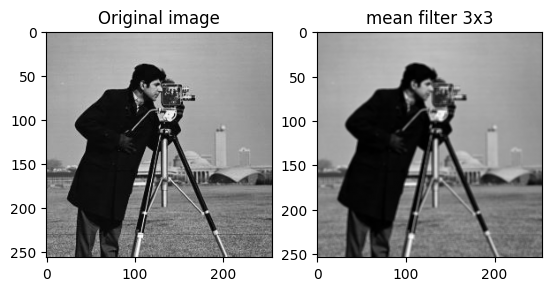

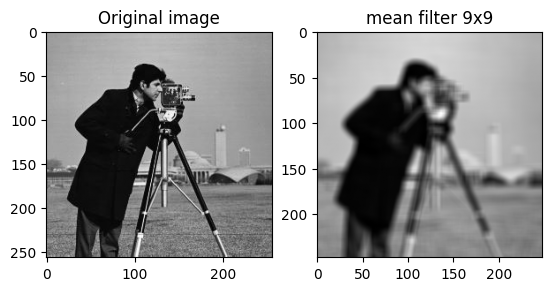

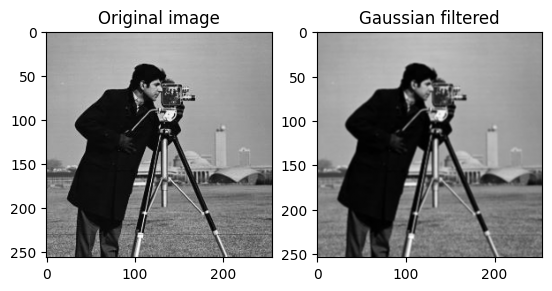

In [5]:
############################################################
# MEAN FILTER
############################################################

bias = np.asarray([0])
bias = bias.reshape((1, 1, 1, 1))

mean_filter_3 = np.ones(shape=(3, 3, 1, 1), dtype=np.float32)
mean_filter_3 = mean_filter_3/9.0

mean_filter_9 = np.ones(shape=(9, 9, 1, 1), dtype=np.float32)
mean_filter_9 = mean_filter_9/81.0

mean_3x3 = convolution(X, mean_filter_3, bias, pad=0, stride=1)
mean_9x9 = convolution(X, mean_filter_9, bias, pad=0, stride=1)

plt.figure(0)
plt.subplot(1, 2, 1)
plt.imshow(image[:, :, 0], cmap='gray')
plt.title('Original image')
plt.subplot(1, 2, 2)
plt.imshow(mean_3x3[0, :, :, 0], cmap='gray')
plt.title('mean filter 3x3')

plt.figure(2)
plt.subplot(1, 2, 1)
plt.imshow(image[:, :, 0], cmap='gray')
plt.title('Original image')
plt.subplot(1, 2, 2)
plt.imshow(mean_9x9[0, :, :, 0], cmap='gray')
plt.title('mean filter 9x9')


############################################################
# GAUSSIAN FILTER
############################################################

gaussian_filter = np.asarray(
    [[1, 2, 1],
     [2, 4, 2],
     [1, 2, 1]],
     dtype=np.float32
)
gaussian_filter = gaussian_filter.reshape(3, 3, 1, 1)
gaussian_filter = gaussian_filter/16.0

gaussian_smoothed = convolution(X, gaussian_filter, bias, pad=0, stride=1)

plt.figure(3)
plt.subplot(1, 2, 1)
plt.imshow(image[:, :, 0], cmap='gray')
plt.title('Original image')
plt.subplot(1, 2, 2)
plt.imshow(gaussian_smoothed[0,:,:,0], cmap='gray')
plt.title('Gaussian filtered')


__Optional__: Now load a color image and apply the mean filtering and Gaussian filtering on this color image.
Not much changes at the call of the convolution operation, you just need to "play" with the convolutional kernels configurations.

C:\Users\Andreea\AppData\Local\Temp\ipykernel_33976\3569382599.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a = a + float(b)


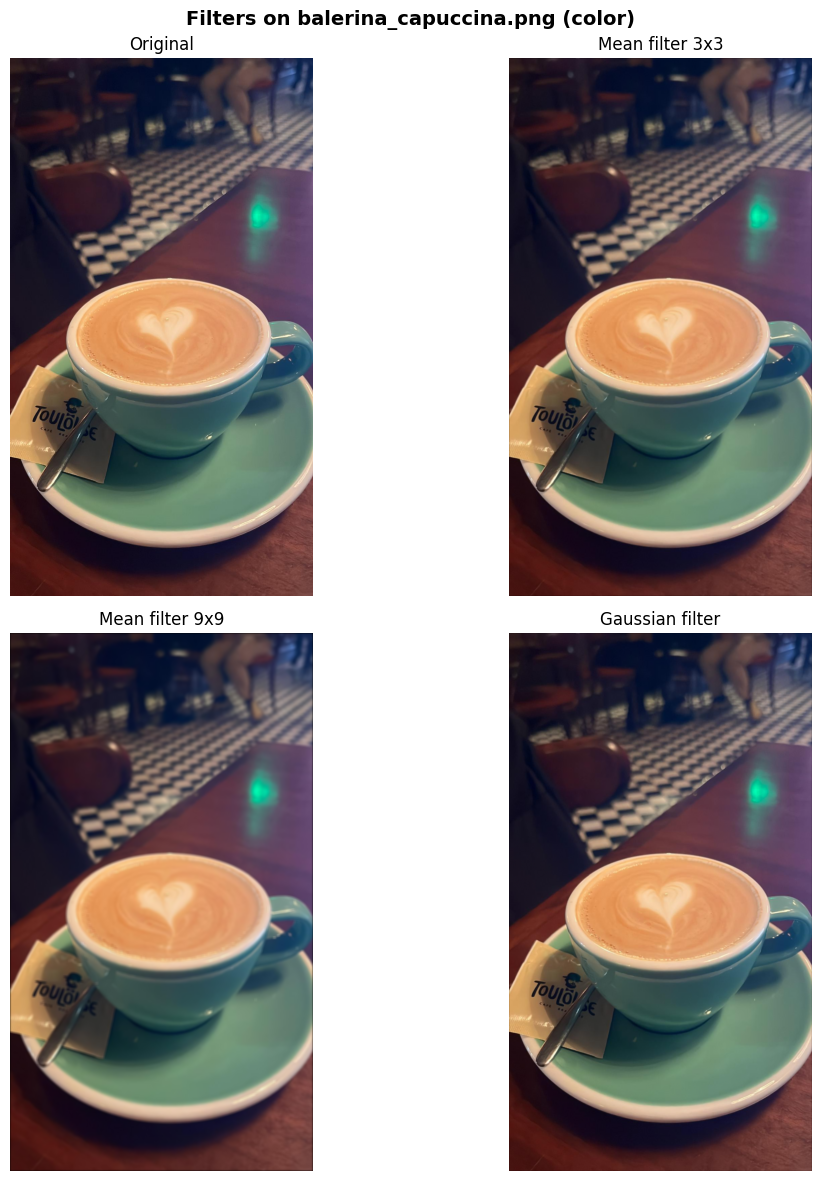

In [8]:
img_color = cv2.imread('balerina_capuccina.png')
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB).astype(np.float32)

bias = np.zeros((1, 1, 1, 3))

# Apply filters per-channel: shape (fs, fs, 1, 3) with each filter slice on one channel
mean_filter_3 = np.zeros((3, 3, 1, 3), dtype=np.float32)
for c in range(3):
    mean_filter_3[:, :, 0, c] = 1.0 / 9.0

mean_filter_9 = np.zeros((9, 9, 1, 3), dtype=np.float32)
for c in range(3):
    mean_filter_9[:, :, 0, c] = 1.0 / 81.0

gauss_2d = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16.0
gaussian_filter = np.zeros((3, 3, 1, 3), dtype=np.float32)
for c in range(3):
    gaussian_filter[:, :, 0, c] = gauss_2d

# Process each channel separately and stack back to RGB
def apply_filter_color(img, filt, bias_val, pad, stride):
    results = []
    for c in range(3):
        channel = img[:, :, c:c+1]
        X_ch = channel[np.newaxis, :, :, :]
        f_ch = filt[:, :, :, c:c+1]
        b_ch = np.zeros((1, 1, 1, 1))
        out = convolution(X_ch, f_ch, b_ch, pad=pad, stride=stride)
        results.append(out[0, :, :, 0])
    return np.stack(results, axis=2)

mean_3x3 = apply_filter_color(img_color, mean_filter_3, bias, pad=1, stride=1)
mean_9x9 = apply_filter_color(img_color, mean_filter_9, bias, pad=4, stride=1)
gaussian_smoothed = apply_filter_color(img_color, gaussian_filter, bias, pad=1, stride=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow((img_color / 255.0).clip(0, 1))
axes[0, 0].set_title("Original")
axes[0, 1].imshow((mean_3x3 / 255.0).clip(0, 1))
axes[0, 1].set_title("Mean filter 3x3")
axes[1, 0].imshow((mean_9x9 / 255.0).clip(0, 1))
axes[1, 0].set_title("Mean filter 9x9")
axes[1, 1].imshow((gaussian_smoothed / 255.0).clip(0, 1))
axes[1, 1].set_title("Gaussian filter")

for ax in axes.flatten():
    ax.axis("off")
plt.suptitle("Filters on balerina_capuccina.png (color)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### High pass filters

On the other hand, high pass filters are used to highlight the high frequency information in an image (edges, abrupt changes in intensities).

One of the most commonly used high pass filters is the Sobel kernel (depicted below). These filters can be seen as discrete differentiation operators, and they compute an approximation of the gradient (on the horizontal or vertical direction) of the image intensity function.

<img src="https://i.ytimg.com/vi/W7OpxFbrD84/maxresdefault.jpg" width=300px/>

C:\Users\Andreea\AppData\Local\Temp\ipykernel_33976\3569382599.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a = a + float(b)


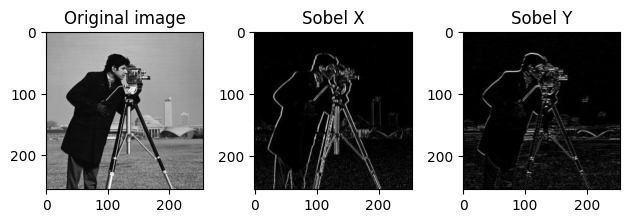

In [6]:
sobel_horiz = np.asarray([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]])

sobel_vert = sobel_horiz.T

sobel_horiz = np.reshape(sobel_horiz, (3, 3, 1, 1))
sobel_vert = np.reshape(sobel_vert, (3, 3, 1, 1))

sobel_x = convolution(X, sobel_horiz, bias, 0, 1)
sobel_y = convolution(X, sobel_vert, bias, 0, 1)


plt.subplot(1, 3, 1)
plt.imshow(image[:, :, 0], cmap='gray')
plt.title('Original image')
plt.subplot(1, 3, 2)
plt.imshow(np.abs(sobel_x[0,:,:,0])/np.abs(np.max(sobel_x[0,:,:,0]))*255, cmap='gray')
plt.title('Sobel X')
plt.subplot(1, 3, 3)
plt.imshow(np.abs(sobel_y[0,:,:,0])/np.abs(np.max(sobel_y[0,:,:,0]))*255, cmap='gray')
plt.title('Sobel Y')
plt.tight_layout()


# <font color='red'> Optional </font>  
## Pooling

The pooling layer is used to reduce the spatial dimension of the activation maps, and thus the computational burden. It has no learnable parameters and it operates individually across each input channel and resizes it spatially.

The two most common types of pooling are max pooling and average pooling.


The hyperparameters of a pooling layer are:
- the filter size F (usually this is an odd value);
- the stride S (or the step used when sliding across the input volume);

Given an input volume of shape  ($H_i$, $W_i$, $D$), the convolutional layer will produce an output of shape ($H_o$, $W_o$, $D$), where:

\begin{equation}
W_o = \frac{W_i - F}{S} + 1
\end{equation}

\begin{equation}
H_o = \frac{H_i - F}{S} + 1
\end{equation}

An illustration of the pooling operation is depicted in the image below:

![picture](https://www.researchgate.net/profile/Alla-Eddine-Guissous/publication/337336341/figure/fig15/AS:855841334898691@1581059883782/Example-for-the-max-pooling-and-the-average-pooling-with-a-filter-size-of-22-and-a.jpg)

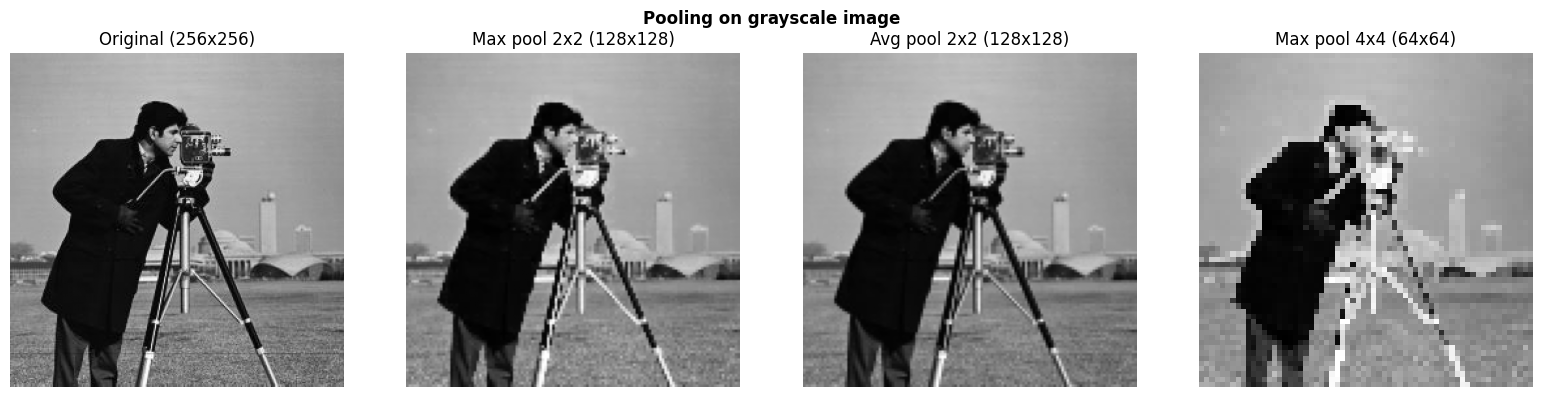

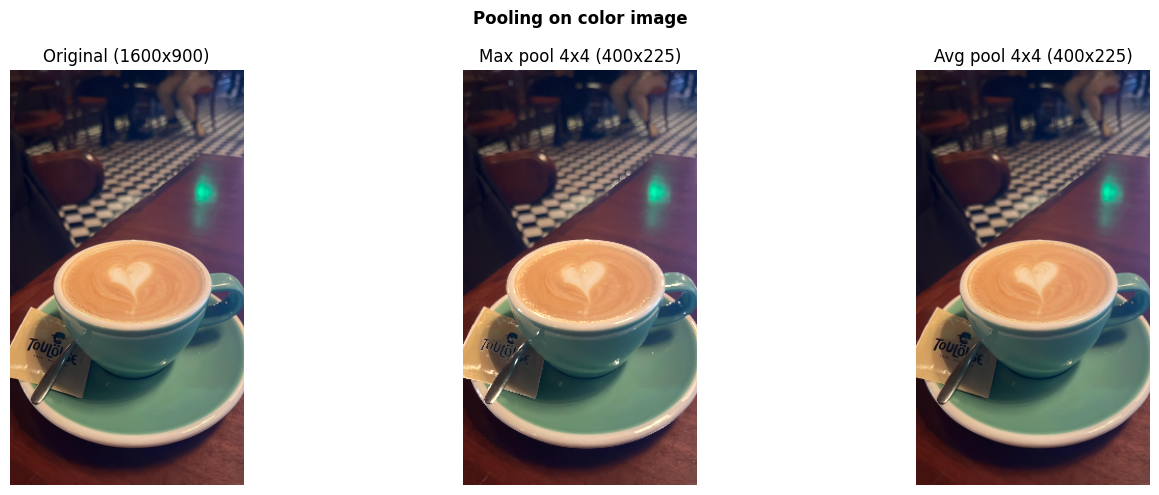

In [9]:
def pooling(X, filter_size, stride, type):
    """
    Implements the pooling operation

    :param X - input volume of shape (num_samples, H, W, C)
    :param filter_size - the size of the pooling
    :param stride - the stride of the pooling operation
    :param type - can be 'max' or 'avg'; the type of the pooling operation to apply

    Returns the output of the pooling operation.
    """
    num_samples, iH, iW, iC = X.shape
    f = filter_size

    oH = (iH - f) // stride + 1
    oW = (iW - f) // stride + 1

    output = np.zeros((num_samples, oH, oW, iC))

    for i in range(num_samples):
        for y in range(oH):
            tl_y = y * stride
            br_y = tl_y + f
            for x in range(oW):
                tl_x = x * stride
                br_x = tl_x + f

                roi = X[i, tl_y:br_y, tl_x:br_x, :]

                if type == 'max':
                    output[i, y, x, :] = roi.max(axis=(0, 1))
                elif type == 'avg':
                    output[i, y, x, :] = roi.mean(axis=(0, 1))

    return output


# Grayscale pooling
img_gray = cv2.imread('cameraman.jpg', cv2.IMREAD_GRAYSCALE).astype(np.float32)
X_gray = img_gray[np.newaxis, :, :, np.newaxis]

max_2x2 = pooling(X_gray, filter_size=2, stride=2, type='max')
avg_2x2 = pooling(X_gray, filter_size=2, stride=2, type='avg')
max_4x4 = pooling(X_gray, filter_size=4, stride=4, type='max')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title(f"Original ({img_gray.shape[0]}x{img_gray.shape[1]})")
axes[1].imshow(max_2x2[0, :, :, 0], cmap='gray')
axes[1].set_title(f"Max pool 2x2 ({max_2x2.shape[1]}x{max_2x2.shape[2]})")
axes[2].imshow(avg_2x2[0, :, :, 0], cmap='gray')
axes[2].set_title(f"Avg pool 2x2 ({avg_2x2.shape[1]}x{avg_2x2.shape[2]})")
axes[3].imshow(max_4x4[0, :, :, 0], cmap='gray')
axes[3].set_title(f"Max pool 4x4 ({max_4x4.shape[1]}x{max_4x4.shape[2]})")
for ax in axes:
    ax.axis("off")
plt.suptitle("Pooling on grayscale image", fontweight="bold")
plt.tight_layout()
plt.show()

# Color pooling
img_c = cv2.cvtColor(cv2.imread('balerina_capuccina.png'), cv2.COLOR_BGR2RGB).astype(np.float32)
X_c = img_c[np.newaxis, :, :, :]

max_c = pooling(X_c, filter_size=4, stride=4, type='max')
avg_c = pooling(X_c, filter_size=4, stride=4, type='avg')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow((img_c / 255.0).clip(0, 1))
axes[0].set_title(f"Original ({img_c.shape[0]}x{img_c.shape[1]})")
axes[1].imshow((max_c[0] / 255.0).clip(0, 1))
axes[1].set_title(f"Max pool 4x4 ({max_c.shape[1]}x{max_c.shape[2]})")
axes[2].imshow((avg_c[0] / 255.0).clip(0, 1))
axes[2].set_title(f"Avg pool 4x4 ({avg_c.shape[1]}x{avg_c.shape[2]})")
for ax in axes:
    ax.axis("off")
plt.suptitle("Pooling on color image", fontweight="bold")
plt.tight_layout()
plt.show()

# Convolutional Neural Networks in pytorch


In this laboratory, you'll be using convolutional neural networks (CNNs) to perform image classification in torch.
You'll follow two approaches:
- First, you'll design, implement, and train a simple network **from scratch**. However, in practice, you won't get to train an entire CNN from scratch (with random initialization), because it is relatively rare to have a dataset of sufficient size. Instead, the norm is to pre-train a CNN on a very large dataset and then use these weights as an initialization or a fixed feature extractor for the task of interest (transfer learning).
- Therefore, in the second part you'll use **transfer learning** to fine-tune an already trained model on your dataset. Transfer learning is a machine learning technique where a model pre-trained on one task is adapted to a different, but related, task. This approach leverages the knowledge and features learned during the initial training to improve performance and reduce data requirements for the new task, making it more efficient and effective.


The main pipeline when training a neural network model is:
1. "Get one with the data". Analyze your input images,
2. Define the model (start with something simple in the beginning)
3. Define the training setup
4. Train the model
5. Test and *analyze* the results.
*Repeat the steps 2-5*


# 1. Datasets and data loaders


You will be working with the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/), which is a 37 category pet dataset with roughly 200 images for each class. The images have large variations in scale, pose, and lighting, and they are annotated with the breed of the pet (37 classes), the head ROI, and pixel-level trimap segmentation.


*Datasets* and *DataLoader* are the core pytorch data structures for interacting with your data. Ideally, you would want your data handling code to be completely decoupled from the model training and testing code (you'll often need to evaluate your model on different datasets).


``torch.utils.data.Dataset`` stores the actual information about the dataset (the samples and their corresponding ground truth labels), while the torch.``utils.data.DataLoader`` wraps an iterable around the dataset, allowing easy access to the data, automatic batching, and multi-process data loading).


For now, you'll use the OxfordPets dataset implementation from [torchvision](https://pytorch.org/vision/stable/generated/torchvision.datasets.OxfordIIITPet.html), but next time you'll be learning how you can create your own custom dataset and how to configure data loaders.
torchvision is a popular package that comprises popular datasets, model architectures, and common image transformations for computer vision.


Transforms are common image transformations available in the ``torchvision.transforms`` module and can be used to preprocess and augment the input data. They can be chained together using *Compose*.
You can also use it to augment your data.
Image augmentation generates similar but distinct training examples after a series of random changes to the training images, and can help reduce overfitting.




```
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


```




# 2. The Convolutional Neural Network

## Convolutional Neural Networks for scratch

Check the tutorial from reference [[2]](#scrollTo=my1Fk-G5KKmz&line=2&uniqifier=1).

You'll define your convolutional neural network by extending the [torch.nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class, which is the base class for all the neural network modules.
In the constructor, you define the layers (and their properties) that comprise your module. ``torch.nn`` [package](https://pytorch.org/docs/stable/nn.html) provides classes for the basic layers of a CNN.

The function that you need to override is the _forward()_ function in which you specify computation performed at every call (i.e. how are layers chained and how does the data flow over the computational graph). In other words, this defines the forward pass through your model.



## Transfer learning


Check the tutorial from reference [[3]](#scrollTo=my1Fk-G5KKmz&line=2&uniqifier=1).


The ``torchvision`` module provides the implementation and pre-trained weights for common neural network architectures.
For example, to load the resnet18 architecture and its weights (after training on ImageNet, you can use:


```[python]
from torchvision.models import resnet18, ResNet18_Weights


# Using pretrained weights:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
```

 Remember from the first lab, that when using a pre-trained model you must preprocess to the image as the images used for training the model. Using the correct preprocessing method is critical and failing to do so may lead to decreased accuracy or incorrect outputs. Each architecture uses a different preprocessing technique, so there is no standard way to achieve this.


#### Note (transfer learning training)
 In the tutorial, you will notice that the authors use model.train() and model.eval() in the training loop. These functions "tell" the model how to act when it is being run. In the next lectures, you will learn that some layers (such as dropout, batch normalization, and so on) behave differently during train and evaluation, and hence the model will produce unexpected results if run in the wrong mode. So don't forget these steps.


 To freeze the weights of the model and train only the rest, you can set requires_grad of the parameters you want to freeze to False.
```
for param in model.features.parameters():
    param.requires_grad = False
```


On the other hand, the ``torch.no_grad()``context manager that we used in the prvious lab  is used to prevent calculating gradients in the following code block. Usually it is used when you evaluate your model and don’t need to call backward() to calculate the gradients and update the corresponding parameters. In this mode, the result of every computation will have ``requires_grad=False``, even when the inputs have ``requires_grad=True``.



# 3. Training the model


For training, we need to define a loss function and an optimizer. We'll cover optimizers next time, in this laboratory we'll just stick to stochastic gradient descent.


Let's first define some concepts:
- epoch: an epoch defines a pass through the entire training dataset. The number of epochs (passes of the entire training dataset the machine learning algorithm has completed) is a hyperparameter of your model. An epoch consists of one or more batches.
- batch:  a batch defines how many samples your model "sees" before updating its weights. In other words, the batch size is the number of samples that will be passed through to the network at one time during its training.
- sample: a sample is just a single training example.


As you saw in the previous laboratory, a typical training loop looks like this:
```


optimizer - the chosen optimizer. It holds the current state of the model and will update the parameters based on the computed gradients. Notice that in the constructor of the optimizer you need to pass the parameters of your model and the learning rate.
criterion - the chosen loss function.


for epoch in range(num_epochs):  # num_epochs is a hyperparameter that specifies when is the training process


    running_loss = 0.0
    for i, data in enumerate(dataloader, 0): # iterate over the dataset, now we use data loaders
        # get a batch of data (inputs and their corresponding labels)
        inputs, labels = data


        # IMPORTANT! set the gradients of the tensors to 0. by default torch accumulates the gradients on subsequent backward passes
        # if you omit this step, the gradient would be a combination of the old gradient, which you have already used to update the parameters
        optimizer.zero_grad()


        # perform the forward pass through the network
        outputs = net(inputs)
       
        # apply the loss function to determine how your model performed on this batch
        loss = criterion(outputs, labels)

        # start the backprop process. it will compute the gradient of the loss with respect to the graph leaves
        loss.backward()


        # update the model parameters by calling the step function
        optimizer.step()


```





Now let's examine the effect of the learning rate over the training process.

- First, create two plots: one in which you plot, for each epoch, the loss values on the training and the test data (two series on the same graph), and another one in which you plot, for each epoch, the accuracy values on the training and the test data.
- Experiment with different values for the learning rate.
- Then, experiment with a torch.optim.lr_scheduler to adjust the learning rate during the training process [doc](!https://pytorch.org/docs/stable/optim.html).

```
optimizer = SGD(model, lr)
scheduler = ExponentialLR(optimizer, gamma=0.9)

for epoch in range(num_epochs):
    for input, target in dataset:
        optimizer.zero_grad()
        output = model(input)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
    # apply the learning rate scheduler
    scheduler.step()
```

Use wandb to track your experiments.



# Using the GPU

``torch`` is designed to allow for computation both on CPU and on GPU.
If your system has a GPU and the required libraries configured for torch compatibility, the cell below will print information about its state.

If you are running your code on colab, you can enable GPU computation from: Runtime->Change Runtime type -> T4 GPU

In [ ]:
import torch
if torch.cuda.is_available():
    !nvidia-smi
else:
    print("NO GPU :( )")

Now we can start to use accelaration.
You now need to explictly specify on which device your tensors reside. You can
move all of the model's parameters `.to` a certain device (the GPU)
and also move the data on the same device there as well
before applying the model and calculating the loss.

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
loss_fn(model(x.to(device)), y.to(device))

# Hyperparameter search with wandb Sweeps

So far, you manually ran a few experiments by changing hyperparameters (learning rate, weight decay, etc.). This works, but it becomes tedious and error-prone as soon as you want to try many combinations. In practice, we automate this process using **sweeps**: a sweep is a structured way to launch multiple runs, each with different hyperparameters, and then compare them in a single place.

Sweeps are most useful when training becomes expensive and the number of choices
becomes large (CNNs, data augmentation, fine-tuning). Instead of manually changing one parameter at a time, a sweep runs many experiments automatically and keeps the results organized so you can compare them fairly.

For CNNs trained from scratch, typical hyperparameters are the learning rate, weight decay, and the learning-rate schedule. For fine-tuning that you did in this lab, the most
important choices are *how much of the pretrained network you update* and *how
large the learning rates are in the backbone versus the new classification head*.

### Grid sweep vs random sweep

A **grid sweep** tries every combination from a small set of values. It is easy to understand, but it scales poorly: if you add one more
hyperparameter, the number of runs can explode.

A **random sweep** samples combinations from ranges/distributions and lets you
decide a fixed run budget (for example 15-20 runs). In practice, random sweeps are
often more efficient than grid sweeps when compute is limited, because they explore
the space more broadly without wasting runs on a dense grid.

Another commonly used practice is to first do a random sweep to roughly determine the hyperparameters, and then do a more focused and smaller grid search around the hyperparameters found by the random sweep.


## Task: run a sweep for fine-tuning

Use wandb Sweeps to run a hyperparameter search for your fine-tuned CNN.

For fine-tuning, we do **not** always want the same learning rate everywhere.
The classification head is new and can learn faster, while the pretrained backbone
should usually be updated more carefully.

In your sweep, use **two learning rates**  `lr_head` for the classification head
and `lr_backbone` for the pretrained backbone (usually 10x smaller).

If you have enough compute also sweep `weight_decay` (regularization) and `freeze_policy` (how much of the backbone you unfreeze).

A simple `freeze_policy` can be:
- `"head_only"` (train only the new head)
- `"last_block"` (unfreeze only the last block + head)
- `"all"` (fine-tune the full network)





## Visualization: understanding what the CNN learned

In this section you will implement several visualization tools **from scratch**.
The goal is not only to obtain nice pictures, but to build intuition about what a
CNN encodes, where it focuses, and why some predictions happen.

You are not allowed to use “ready-made” visualization helpers (e.g. Grad-CAM
libraries). You may use PyTorch hooks and basic tensor operations.


### 1) Nearest neighbours in feature space (retrieval)

Pick a layer that produces a feature representation (for example the output of the backbone right before the final classifier). For every image, extract its feature vector and store it.

For a given query image, find its nearest neighbours in the training set using a
distance in feature space (cosine distance or Euclidean distance). Then display:
the query image, its predicted label, and the top-k nearest neighbours with their labels and distances.

Discuss: do neighbours share semantics (same class, similar shape), or do they
share low-level properties (color, background)? How does this change if you pick
an earlier layer vs a later layer?


### 2) Occlusion sensitivity heatmaps (black patch masking)

In this task you will build a visualization method that answers the question:
“Which parts of the image are most important for this prediction?”

The idea is simple: we repeatedly cover a small region of the input image with a
black patch (occlusion) and measure how the model's output changes. If covering a
region causes a large drop in the predicted score for the correct/target class,
that region was important.

For one image and a chosen target class `c` (usually the predicted class), define `S_c(x)` = the model score for class `c` (use the logit, before softmax).

Now slide a $p \times p$ black patch over the image with stride `s`. For each patch
location `(i, j)`, create an occluded image `x_(i,j)` by setting that patch to
zero (black), then compute the score drop $
\Delta(i,j) = S_c(x) - S_c(x_{(i,j)})
$. `Δ(i, j)` becomes your heatmap value at that patch position.

The steps are:
1. Choose patch size `p` (e.g. 8 or 12) and stride `s` (e.g. 4).
2. Compute the occlusion heatmap `Δ` over the image.
3. Upsample `Δ` to the image resolution and visualize it as a heatmap overlay.
4. Repeat for a few images: at least one correct prediction and one incorrect
   prediction (if possible), and compare the heatmaps.

Comment on what you observe. Do the most “sensitive” regions correspond to the
object? In failure cases, does the network rely on background cues?

Implementation note: this method is slowe because it requires many forward passes (one per patch location). Keep
your patch size/stride reasonable so the computation remains manageable.

### 3) Visualizing patches which maximally activate a neuron (top-activating patches)

In this task you will identify **which image patches** make a chosen neuron/channel
activate the most.

Choose a convolutional layer and a target channel $k$. For an input image, the
activation tensor at that layer has shape $(C, H, W)$. The activation map for the
chosen channel is $A_k$ with shape $(H, W)$. Each spatial location $(i, j)$ in
$A_$` corresponds to a **receptive field** (a patch) in the original input image.

Your task:
1. Pick a layer and a channel $k$.
2. For many images (e.g. the full test set or a large subset), compute $A_k$.
3. Find the top activation locations $(i, j)$ across all images, using the value
   $A_k[i, j]$ as the activation score.
4. For each top activation, extract the corresponding **input patch** from the
   original image (centered at the receptive field of $(i, j)$), and display the
   patches in a grid (top-25).
5. Comment on what visual pattern the channel has learned to detect.

Implementation hint: you need a way to map a feature-map position $(i, j)$ back to
a patch in the input image. You can do this approximately by treating the feature
map as a grid over the input and using a fixed patch size, or more accurately by
computing the receptive field based on kernel sizes and strides.

In the simplest (approximate) approach, you can assume that the feature map forms
a regular grid over the input image. If the input has size `H_in × W_in` and the
feature map has size $H \times W$, then one feature-map cell roughly corresponds
to a patch of size $(H_{\text{in}} / H) \times (W_{\text{in}} / W)$ in the input.
You can map `(i, j)` to the center of this patch and extract a fixed-size window
around it.

More precisely, the receptive field can be computed by propagating kernel sizes,
strides, and padding from the input up to the chosen layer. This gives you the
exact size and position of the input region that affects a given activation.
For this lab, an approximate mapping is sufficient, as long as you state the
assumption you are making.


### 4) Grad-CAM (from scratch)

[Grad-CAM](https://xai-tutorials.readthedocs.io/en/latest/_model_specific_xai/Grad-CAM.html#:~:text=Grad%2DCAM%20(Gradient%2Dweighted%20Class%20Activation%20Mapping)%20is%20a,model%20'looks%20at'%20when%20making%20a%20prediction.) produces a class-specific heatmap showing which regions contributed most
to a chosen class score.

Implement Grad-CAM for a single target convolutional layer:

1) Run a forward pass and store the feature map `A` of shape `(C, H, W)` for that
layer.
2) Select a target class $c$ (usually the predicted class) and compute the score
$S_c$ (logit, before softmax).
3) Compute gradients of $S_c$ with respect to the feature map $A$:
   $dS_c/dA$.
4) Compute channel weights by global-average-pooling the gradients over spatial
dimensions:
   $alpha_k = mean_{i,j} (dS_c/dA_k(i,j))$.
5) Build the Grad-CAM map:
   $L = ReLU( \sum_k alpha_k * A_k )$.
6) Upsample `L` to the image size and overlay it on the input image.

Show Grad-CAM overlays for a correct prediction and an incorrect prediction (if possible).

Discuss: does the model focus on meaningful regions? In the failure case, where
does it look and what might explain the mistake?

#Useful references

- [1] [a "recipe" ](http://karpathy.github.io/2019/04/25/recipe/)  when you will start training artifcial neural networks;
- [2] [Defining a CNN](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) in torch;
- [3] [Transfer learning](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) in torch;
- [4] [model debugging](https://developers.google.com/machine-learning/testing-debugging/common/overview).